In [74]:
import sys, os, torch, pdb
import numpy as np
import torch.nn as nn

sys.path.append('../')
sys.path.append('../../')
cwd = os.getcwd()

from Modules.helpers.performance.density.plotting_loss_running_min import plot_running_min_val_loss_broken_x_log_lst
from Modules.helpers.performance.density.plotting_final_loss import plot_final_loss_lst
from Modules.helpers.performance.plotting_timings import plot_total_run_times_lst
from Modules.helpers.performance.diffusion.plotting_mse_running_min import plot_running_min_MSE_diff_loss_broken_x_log_lst
from Modules.helpers.performance.diffusion.plotting_final_mse import plot_diff_mse_lst
from Modules.helpers.real_space_plotter import symbolic_from_function, plot_eval_D_multi

from Modules.helpers.plotting_profiles import plot_initial_condition_2d, plot_eval2
from file_finder import (paths_to_df,
                         find_data_obj_files, 
                         condense_df,
                         print_path_components)
from Modules.helpers.parse import dictToPath

# Add to main
from data.python.Modules.dataClass import OriginalData, Data
from binn.python.Modules.Models.BuildBINNs_2D import BINN_2d,u_MLP, D_MLP, G_MLP, pde_loss_without_bc_2d, data_loss_MSE, generate_random_inputs_2d
from binn.python.Modules.Utils.ModelWrapper import ModelWrapper


ext  = "dataObj/original?_1/DValue_0.024720000000000002/rValue_1.536/gamma_0.2/K_1700.0/xNum_38/tNum_5/originalDataObj.npy"
data_orig_obj_FKPP = np.load(os.path.join('../../', ext),allow_pickle=True).item(0)

In [75]:
def generate_random_inputs(self,inputs):
    torch.manual_seed(self.loss_count)  
    torch.cuda.manual_seed(self.loss_count)
    samples = torch.rand(self.num_samples*2, 1, requires_grad=True)
    t = samples[:self.num_samples]
    x = samples[self.num_samples:]
    x = x * (self.x_max - self.x_min) + self.x_min
    t = t * (self.t_max - self.t_min) + self.t_min
    return torch.cat([x, t], dim=1).float().to(inputs.device)

def generate_bc_inputs(self, inputs):
    torch.manual_seed(self.loss_count)
    torch.cuda.manual_seed(self.loss_count)
    t = torch.rand(self.num_bcs, 1, requires_grad=True,
                   device=inputs.device) * (self.t_max - self.t_min) + self.t_min
    torch.manual_seed(self.loss_count)
    torch.cuda.manual_seed(self.loss_count)
    selector = torch.randint(0, 2, (self.num_bcs, 1), device=inputs.device, dtype=torch.bool)
    x_left  = torch.full_like(t, self.x_min)
    x_right = torch.full_like(t, self.x_max)
    x = torch.where(selector, x_left, x_right)
    return torch.cat([x, t], dim=1)

def bc_no_flux_loss(self, inputs_bc, u_bc):
    dudx = Gradient(u_bc, inputs_bc, order=1)[:, 0][:, None]   # x–component
    return self.bc_weight * dudx.pow(2)

def apply_constraints(self, D, G, t, u):
    self.D_loss = 0
    self.G_loss = 0
    self.D_loss += self.D_weight*torch.where(
            D <  self.alpha_D_min, (D -self.alpha_D_min)**2, torch.zeros_like(D))
    self.D_loss += self.D_weight*torch.where(
            D >  self.alpha_D_max, (D - self.alpha_D_max)**2, torch.zeros_like(D))
    try:
        dDdu = Gradient(D, u, order=1)
        self.D_loss += self.dDdu_weight*torch.where(
                dDdu < 0.0, dDdu**2, torch.zeros_like(dDdu))
    except:
        pass
    if G is not None:
        self.G_loss += self.G_weight*torch.where(
                G < self.G_min, (G-self.G_min)**2, torch.zeros_like(G)) 
        self.G_loss += self.G_weight*torch.where(
                G > self.G_max, (G-self.G_max)**2, torch.zeros_like(G))
        try:
            dGdu = Gradient(G, u, order=1)
            self.G_loss += self.dGdu_weight*torch.where(
                dGdu > 0.0, dGdu**2, torch.zeros_like(dGdu))
        except:
            pass
    
def pde_loss(self, inputs, outputs):
    x = inputs[:, 0][:,None]
    t = inputs[:, 1][:,None]
    u = outputs.clone()
    d1 = Gradient(u, inputs, order=1)
    ux = d1[:, 0][:, None]
    ut = d1[:, 1][:, None]
    D = self.diffusion(u) if self.diffusion.inputs == 1 else self.diffusion(u, t)
    LHS = ut
    if self.growth:
        G = self.growth(u) if self.growth.inputs == 1 else self.growth(u, t)
        RHS = self.D_max * Gradient(D * ux, inputs)[:, 0][:, None] + self.G_max * G * u
    else:
        RHS = self.D_max * Gradient(D * ux, inputs)[:, 0][:, None]
        G = None
    pde_loss = (LHS - RHS) ** 2
    apply_constraints(self, D, G, t, u)
    return pde_loss + self.D_loss + self.G_loss 

## Choose and load data

In [76]:
x = data_orig_obj_FKPP.x
t = data_orig_obj_FKPP.t
K = 1
inital_path = os.path.join('../../', "DataObj")

# ==================== Display available data objects ====================
data_df = paths_to_df(find_data_obj_files(start_dir = inital_path,
                                           target_filename="data_obj.npy"))
data_df

,full_path,dataX1num,dataX2num,dataTnum,dataK,dataICLabel,dataDiffLabel,dataGrowLabel,dataGamma,dataNoisePercent,dataNoiseSeed,data
0,../../DataObj/dataX1num_12/dataX2num_12/dataTn...,12,12,5,1,cos,const,const,0,0,0,obj.npy
1,../../DataObj/dataX1num_8/dataX2num_8/dataTnum...,8,8,5,1,cos,const,const,0,0,0,obj.npy


In [77]:
x1Num = 8
x2Num = 8
tNum = len(t)
gamma = 0
noise_percent_list = [0]#[0.5, 1, 2, 5]#, 10]  
IC_label = "cos"
diff_label= "const"
grow_label = "const"
seed = 0
results_dict = {}
data_info_dic = {}
# =================== loop over noise ====================
for noise_percent in noise_percent_list:
    data_info = {
        "dataX1num": x1Num,
        "dataX2num": x2Num,
        "dataTnum": tNum,
        "dataK": K,
        "dataICLabel": IC_label,
        "dataDiffLabel": diff_label,
        "dataGrowLabel": grow_label,
        "dataGamma": gamma,
        "dataNoisePercent": noise_percent,
        "dataNoiseSeed": seed
    }
    
    data_df_updated = condense_df(data_df, data_info)
    data_file_path = data_df_updated["full_path"][0]

    # You can process or store results here, e.g.:
    #print(f"Noise = {noise_percent}% -> {data_file_path}")
    # Or collect results:
    data_info_dic[noise_percent] =data_info
    results_dict[noise_percent] = data_file_path

MSE between u and u_clean: 0.0
ABS between u and u_clean [cells]: 0.0
ABS (%) between u and u_clean: nan


/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case11/../Modules/helpers/plotting_profiles.py:136: RuntimeWarning: invalid value encountered in divide
  print("ABS (%) between u and u_clean:", 100 * np.mean(err / dataobj.u_clean))


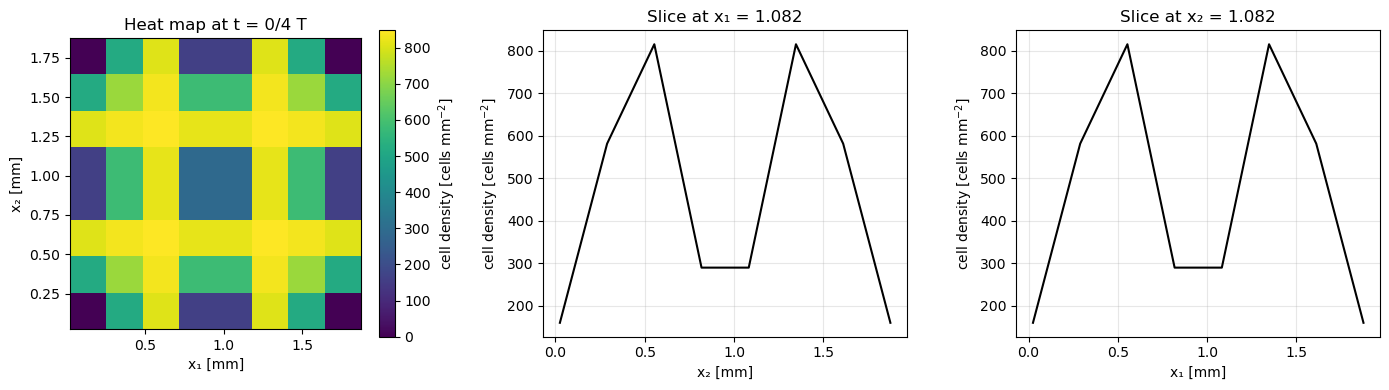

In [78]:
# ==================== Load data object ====================
chosen_noise_idx = 0
chosen_noise = noise_percent_list[chosen_noise_idx]
chosen_noise_path =  results_dict[chosen_noise]
data_obj = np.load(chosen_noise_path,allow_pickle=True).item()
plot_initial_condition_2d(data_obj)

## Choose and load binn model

In [79]:
binn_df = paths_to_df(find_data_obj_files(start_dir='../../', target_filename="binnModel0.pth"))
binn_batch_size = 38
binn_rel_update_thresh = 0.05
binn_rel_save_thresh = 0.05
binn_lr = 1e-3
binn_split_seed = 0

fixed_filters = {
        "dataX1num": x1Num,
        "dataX2num": x2Num,
        "dataTnum": tNum,
        "dataK": K,
        "dataICLabel": IC_label,
        "dataDiffLabel": diff_label,
        "dataGrowLabel": grow_label,
        "dataGamma": gamma,
        "dataNoisePercent": chosen_noise,
        "dataNoiseSeed": seed,
        "binnLR": binn_lr,
        "binnBatchSize": binn_batch_size,
        "binnRelSaveThresh": binn_rel_update_thresh
        }
binn_df1 = condense_df(binn_df, fixed_filters)
binn_df1

,full_path,dataX1num,dataX2num,dataTnum,dataK,dataICLabel,dataDiffLabel,dataGrowLabel,dataGamma,dataNoisePercent,...,binnDevice,BNdataLossFuncLabel,BCbool,numPDEsamples,binnLR,binnBatchSize,binnRelUpdateThresh,binnRelSaveThresh,binnES,binnModelLabel
0,../../binn/dataX1num_8/dataX2num_8/dataTnum_5/...,8,8,5,1,cos,const,const,0,0,...,cpu,MSE,0,100,0.001,38,0.05,0.05,2000,0
1,../../binn/dataX1num_8/dataX2num_8/dataTnum_5/...,8,8,5,1,cos,const,const,0,0,...,cpu,MSE,0,100,0.001,38,0.05,0.05,2000,0
2,../../binn/dataX1num_8/dataX2num_8/dataTnum_5/...,8,8,5,1,cos,const,const,0,0,...,cpu,MSE,0,100,0.001,38,0.05,0.05,2000,0


In [80]:
binnVF = 0.2
binn_model_num = 0
D_one_param_bool = False
G_size = None
binnInitializeDenoiseBool = 0
two_step_bool = 0
binnDevice = "cpu"
BNdataLossFuncLabel = "MSE"
BCbool = 0
numPDEsamples = 100

# =============== USER input ==================
binn_ES_list = [2000]#, 5000]  # list of ES values
binnSplitSeeds = [0]#, 1, 2]
u_NN = 64
D_NN = 4
G_NN = 4
binn_models_by_noise = {}
binn_models_dics = {}
# ==============================================
binn_ext = {
        "binnVF": binnVF,
        "binnGenerateIndicesLabel": "random",
        "binnTVsplitSeed": binnSplitSeeds[0],  
        "binnUsize": u_NN,              
        "binnDsize": D_NN,         
        "binnGsize": G_NN, 
        "DoneParamBool": False,
        "binnDevice": binnDevice,
        "BNdataLossFuncLabel": BNdataLossFuncLabel,
        "BCbool": BCbool,
        "numPDEsamples": numPDEsamples,
        "binnLR": binn_lr,
        "binnBatchSize": binn_batch_size,
        "binnRelUpdateThresh": binn_rel_update_thresh,
        "binnRelSaveThresh": binn_rel_save_thresh,
        "binnES": binn_ES_list[0],
        "binnModelLabel":          binn_model_num,
}
binn_info = data_info.copy()
for ES in binn_ES_list:
    print(f"Loading BINN models for ES = {ES}...")
    binn_models_dics[ES] = {}
    for noise in noise_percent_list:
        binn_info = data_info_dic[noise].copy()
        binn_ext["binnES"] = ES
        binn_models_dics[ES][noise] = {}
        for binnSplitSeed in binnSplitSeeds:
            # Update model parameters
            binn_ext["binnTVsplitSeed"] = binnSplitSeed
            binn_info.update(binn_ext)
            path_to_models = os.path.join("../../binn", dictToPath(binn_info))
            file_path = os.path.join(path_to_models, f'binnModel{binn_model_num}.pth')
            binn_loaded = torch.load(file_path, weights_only=False)
            binn_loaded.load_best_val()
            binn_models_dics[ES][noise][binnSplitSeed] = binn_loaded
diff_test = binn_models_dics[2000][0][0].model.diffusion
total_p = sum(p.numel() for p in diff_test.parameters())
print(f"Number of parameters for dn NN  = {total_p}\n")


Loading BINN models for ES = 2000...
Number of parameters for dn NN  = 53



/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case11/../Modules/helpers/performance/density/plotting_loss_running_min.py:222: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(left=x_min, right=break_x)
/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case11/../Modules/helpers/performance/density/plotting_loss_running_min.py:385: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: ../pngs/1D/Case11/plot_varyNoise/binn/NNu64_dataGamma0.png


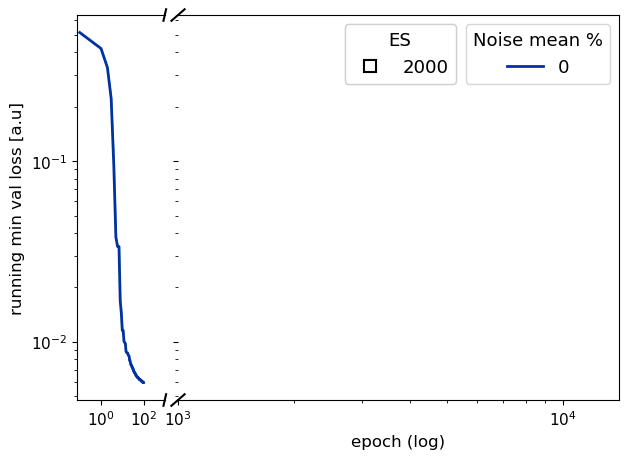

All x-axis labels found (ordered): ['0']
saved plot: ../pngs/1D/Case11/plot_varyNoise/binn/NNu64_dataGamma0_loss_bars.png


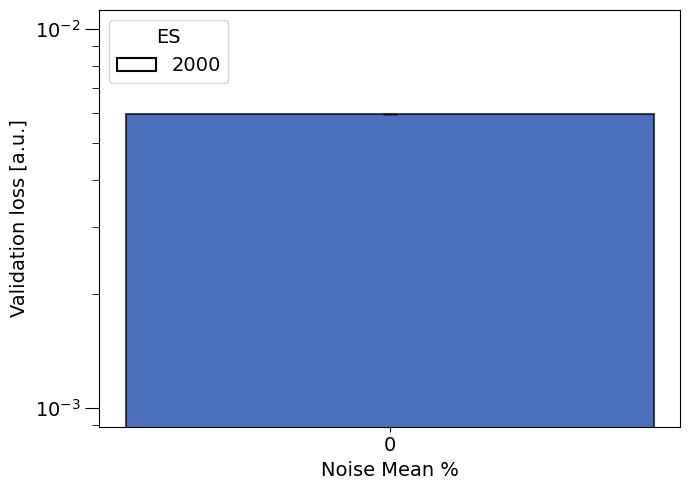

In [81]:
binn_plot = 1
binn_plot_density = True
binn_plot_times = 1

blue_colors = [
    "#0033A0", 
    "#1E90FF", 
    "#6699CC", 
    "#A4C8E1", 
    "#D6EAF8"             
]#[::-1]


linestyles = ['-']*5
marker_styles = ['o']*5

def form_labels_binn(models_dics):
    return [f"{key}" for key in models_dics.keys()]

ES_chosen = binn_ES_list[0]
binn_models_dics_chosen_ES = binn_models_dics[ES_chosen]
labels = form_labels_binn(binn_models_dics_chosen_ES)


model_keys = list(binn_models_dics_chosen_ES.keys())


plot_params = {
    key: [blue_colors[i], linestyles[i], marker_styles[i], labels[i]]
    for i, key in enumerate(model_keys)
}
  

binn_models_by_ES = []
for binn_models_dics_item in list(binn_models_dics.values()):
    binn_models_by_ES.append(binn_models_dics_item)


name_intro = f"../pngs/1D/Case11/plot_varyNoise/binn"
os.makedirs(name_intro, exist_ok=True)
name_full = os.path.join(name_intro, f'NNu64_dataGamma{gamma}.png')

plot_settings = {
    'name': name_full,
    'fill': True,
    'line_width':2,
    'legend': {
        'panel': 2,
        'loc': (1,1),
        "loc_upd": (0.65, 1),
        'fontsize': 13,
        'ncols': 1,
        "title": "Noise mean %"
    },
    'xaxis': {
        'min': 0,
        'max': 1.4e4,
        'break': 1e3
    },
    'line_lengths': {
        'hlength': 7.5e3,
        'vlength_factor': 2
    },
    'line_widths_on_axis': {
        'hwidth': 2,
        'vwidth': 2
    },
    'fontsizes': {'xaxis':12, 'xtick_labels':11, 'yaxis':12, 'ytick_labels':11},
    "figsize": (7, 5),
    "es_entries": [
        (binn_ES_list[0], "s")
    ]
}




if binn_plot:  
    plot_running_min_val_loss_broken_x_log_lst(models_dics_list =binn_models_by_ES,
                                             plot_params=plot_params,
                                             plot_settings=plot_settings)
    bbox_to_anchor=(0,1)
    name_full = os.path.join(name_intro, f'NNu64_dataGamma{gamma}_loss_bars.png')
    plot_final_loss_lst(binn_models_by_ES,
                                plot_params=plot_params,
                                label_list=[f"{ES}" for ES in binn_ES_list],
                                 name=name_full,
                                 bbox_to_anchor=bbox_to_anchor,
                                 y_label="Validation loss [a.u.]",
                                 legend_size=14,
                                 figsize=(7, 5),
                                 x_label="Noise Mean %")



All x-axis labels found (ordered): ['0']
saved plot: ../pngs/1D/Case11/plot_varyNoise/binn/NNu64_dataGamma0_times.png


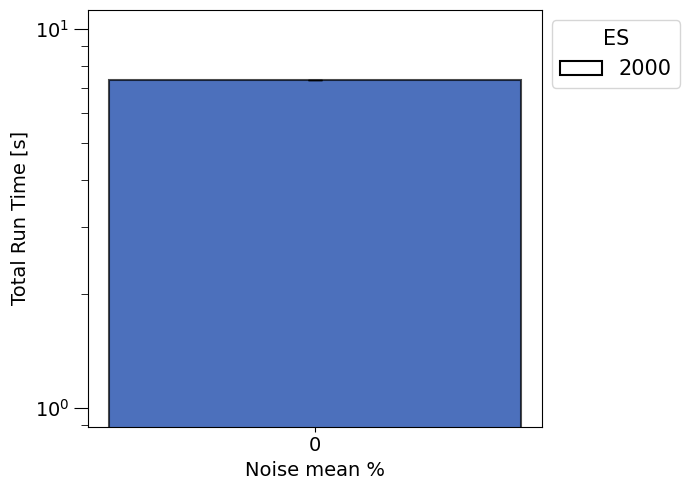

In [82]:
if binn_plot_times:
    name_full = os.path.join(name_intro, f'NNu64_dataGamma{gamma}_times.png')
    plot_total_run_times_lst(models_dics_list=binn_models_by_ES,
                                plot_params=plot_params,
                                label_list=[f"{ES}" for ES in binn_ES_list],
                                legend_pos=(1, 1),
                                legend_fontsize=15,
                                 name=name_full,
                                 x_label = "Noise mean %")



/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case11/../Modules/helpers/performance/diffusion/plotting_mse_running_min.py:242: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax1.set_xlim(left=x_min, right=break_x)
/Users/willa954/Desktop/Git-personal/arXiv_BINN_2D/Training/JN/case11/../Modules/helpers/performance/diffusion/plotting_mse_running_min.py:397: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved plot: ../pngs/1D/Case11/plot_varyNoise/diff/NNu64_dataGamma0_D_mse.png


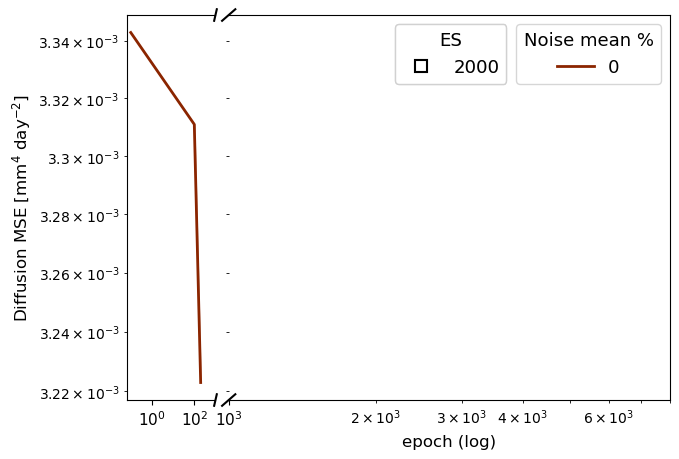

In [83]:
D_colors = [
    "#8B2500",  # Burnt Orange – deep and bold
    "#FF7F0E",  # Vivid Orange – saturated, readable, classic plot color
    "#FDB863",  # Soft Tangerine – warm midtone
    "#FDD9B5",  # Peach – light orange-beige, easy on the eyes
    "#FFF1E0",  # Cream – very light accent, background-compatible
]#[:len(widths)]



u_colors = [
    "#0033A0", 
    "#1E90FF", 
    "#6699CC", 
    "#A4C8E1", 
    "#D6EAF8"             
]#[:len(widths)]
                               # hatch by depth


name_intro = f"../pngs/1D/Case11/plot_varyNoise/diff"
name_full = os.path.join(name_intro, f'NNu64_dataGamma{gamma}_D_mse.png')
os.makedirs(name_intro, exist_ok=True)

plot_params = {
    key: [D_colors[i], linestyles[i], marker_styles[i], labels[i]]
    for i, key in enumerate(model_keys)
}
  

plot_settings = {
    'name': name_full,
    'fill': True,
    'line_width':2,
    'legend': {
        'panel': 2,
        'loc': (1,1),
        'loc_upd': (0.65, 1),
        'fontsize': 13,
        'ncols': 1,
        'title': "Noise mean %"
    },
    'xaxis': {
        'min': 0,
        'max': 0.8e4,
        'break': 1e3
    },
    'line_lengths': {
        'hlength': 7.5e3,
        'vlength_factor': 2
    },
    'line_widths_on_axis': {
        'hwidth': 2,
        'vwidth': 2
    },
    'fontsizes': {'xaxis':12, 'xtick_labels':11, 'yaxis':12, 'ytick_labels':11},
    "figsize": (7, 5),
    "es_entries": [
        (binn_ES_list[0], "s")
    ]
}



  
_ = plot_running_min_MSE_diff_loss_broken_x_log_lst(models_dics_list=binn_models_by_ES,
                                            plot_params=plot_params,
                                            plot_settings=plot_settings)



In [84]:
binn_models_by_ES

[{0: {0: <binn.python.Modules.Utils.ModelWrapper.ModelWrapper at 0x323a18b80>}}]

Scale factor k = 1.02
MSE over [0, 1]: 2.444313599999991e-07
Mean absolute percentage error over [0, 1]: 1.9999999999999962
Scale factor k = 1.05
MSE over [0, 1]: 1.5276960000000024e-06
Mean absolute percentage error over [0, 1]: 5.0000000000000036
Scale factor k = 1.1
MSE over [0, 1]: 6.11078400000001e-06
Mean absolute percentage error over [0, 1]: 10.000000000000007
Scale factor k = 1.2
MSE over [0, 1]: 2.444313599999997e-05
Mean absolute percentage error over [0, 1]: 19.999999999999986
All x-axis labels found (ordered): ['0']
saved plot: ../pngs/1D/Case11/plot_varyNoise/diff/NNu64_dataGamma0_D_loss_bars.png


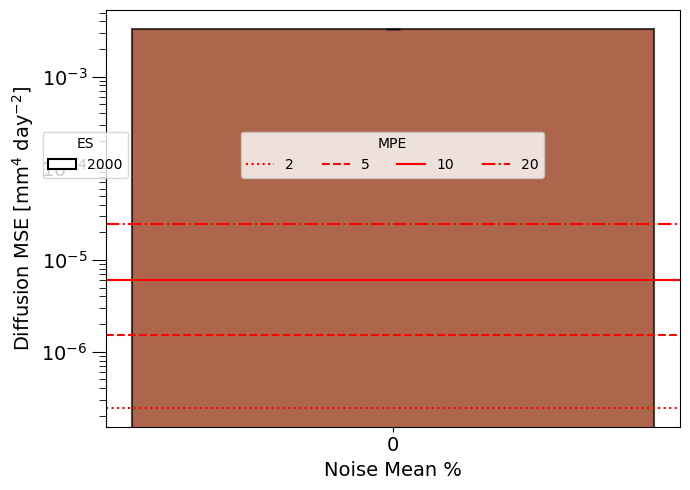

In [85]:
import numpy as np

def make_C_from_D(D, beta, n_points=1001):
    """
    Create a new function C(u) = k * D(u) such that the
    mean absolute percentage error is beta (%), and print
    MSE and absolute percentage error for u in [0, 1].

    Parameters
    ----------
    D : callable
        Original function D(u).
    beta : float
        Target absolute percentage error in percent.
    n_points : int
        Number of points in [0, 1] to use for error calculation.

    Returns
    -------
    C : callable
        New scaled function C(u) = k * D(u).
    """
    # Scale factor so that APE = beta (%)
    k = 1.0 + beta / 100.0  # could also use 1 - beta/100.0

    def C(u):
        return k * D(u)

    # Sample u in [0, 1]
    u = np.linspace(0.0, 1.0, n_points)
    D_vals = np.array([D(ui) for ui in u])
    C_vals = k * D_vals

    # Mean Squared Error over [0, 1]
    mse = np.mean((C_vals - D_vals) ** 2)

    # Mean Absolute Percentage Error (%)
    # avoid division by zero if D(u) = 0 somewhere
    mask = D_vals != 0
    if np.any(mask):
        ape = np.mean(
            np.abs((C_vals[mask] - D_vals[mask]) / D_vals[mask])
        ) * 100.0
    else:
        ape = np.nan  # undefined if D(u) is identically zero

    print(f"Scale factor k = {k}")
    print(f"MSE over [0, 1]: {mse}")
    print(f"Mean absolute percentage error over [0, 1]: {ape}")

    return C, mse, ape

# From file path info contstruct true D

def true_diffusion(u):
    return data_obj.theta_D * np.ones_like(u)


    #print("check PE:", np.mean(100*np.abs(alpha - D_true)/D_true))
mses = []
beta_list = [2,5,10,20]
for beta in beta_list:
    _,mse, ape =  make_C_from_D(true_diffusion, beta=beta)
    mses.append(mse)


plot_params = {
    key: [blue_colors[i], linestyles[i], marker_styles[i], labels[i]]
    for i, key in enumerate(model_keys)
}

name_full = os.path.join(name_intro, f'NNu64_dataGamma{gamma}_D_loss_bars.png')

plot_diff_mse_lst(binn_models_by_ES,
                  plot_params=plot_params,
                  label_list=[f"{ES}" for ES in binn_ES_list],
                  name=name_full,
                  figsize=(7, 5),
                  bbox_to_anchor=(0.05, 0.725),
                  legend_size=10,
                  colors = D_colors,
                  pe_bbox_to_anchor_offset=(0.725, 0),
                  pe_label_list=[f"{beta}" for beta in beta_list],
                  pe_values=mses,
                  pe_linestyles=(":", "--","-", "-."),
                  pe_legend_ncols=4,
                  x_label=r"Noise Mean %")

saved plot: ../pngs/1D/Case11/plot_varyNoise/diff/NNu64_dataGamma0_diffusion_plots.png


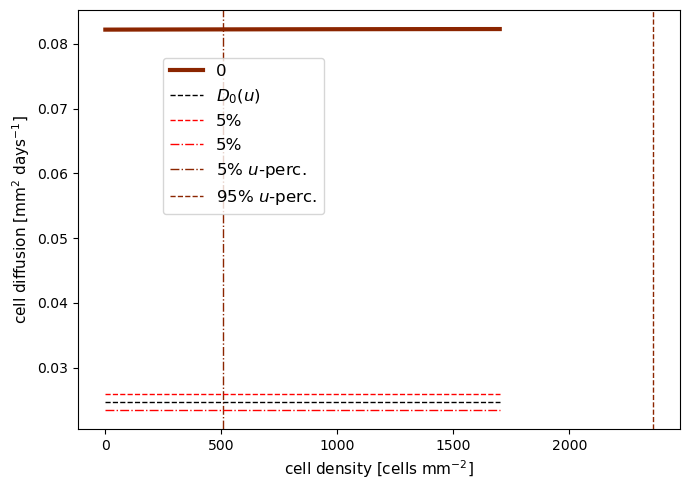

In [86]:

# --- Diffusion models ---
diffusion_models = {
    "const":     (lambda u, a: np.full_like(u, a), [0.02472]),
    "linear":    (lambda u, a, b: a + b * u,         [0.015, 0.06]),
    "quadratic": (lambda u, a, b: a + b * u**2,      [0.01, 0.044]),
    "exp":       (lambda u, a, b, c: a + b * (1 - sp.exp(-c * u)), [0.003, 0.095, 2.5])
}

# --- Growth models ---
growth_models = {
    "const":     (lambda u, a: np.full_like(u, a) / 2,          [1.3]),
    "linear":    (lambda u, a, b: (a + b * u) / 2,              [2.4, -3]),
    "quadratic": (lambda u, a, b: (a + b * u**2) / 2,           [2.1, -0.29]),
    "exp":       (lambda u, a, b, c: (a + b * (1 - sp.exp(-c * u))) / 2, [0.7, 1.3, -4]),
    "zero":      (lambda u, _: np.full_like(u, 0.0),            [0])
}

# --- Function dispatch ---
diff_func, theta_D = diffusion_models[diff_label]
grow_func, theta_G = growth_models[grow_label]

def diffusion_func(u):
    return diff_func(u, *theta_D)

def growth_func(u):
    return grow_func(u, *theta_G)
D_sym_true = symbolic_from_function(diffusion_func)
D_sym_true_lst = [D_sym_true]

name_intro = f"../pngs/1D/Case11/plot_varyNoise/diff"
name_full = os.path.join(name_intro, f'NNu64_dataGamma{gamma}_diffusion_plots.png')


orange_colors = [
    "#8B2500",  # Burnt Orange – deep and bold
    "#FF7F0E",  # Vivid Orange – saturated, readable, classic plot color
    "#FDB863",  # Soft Tangerine – warm midtone
    "#FDD9B5",  # Peach – light orange-beige, easy on the eyes
    "#FFF1E0",  # Cream – very light accent, background-compatible
]
err_up=5
err_low=5
errs = [err_up, err_low]


binn_models_dics_chosen_ES1000 = {
    f"{d}": width_dict for d, width_dict in binn_models_by_ES[0].items() 
}

# binn_models_dics_chosen_ES2000 = {
#     f"{d} | ES2000": width_dict for d, width_dict in binn_models_by_ES[1].items() 
# }
# Combine both dicts now safely
binn_models_combined = {**binn_models_dics_chosen_ES1000}
                       # **binn_models_dics_chosen_ES2000}

labels = list(binn_models_combined.keys())


plot_eval_D_multi(binn_models_combined,
                 data_obj, 
                D_sym_true_lst, 
               orange_colors, 
               labels, 
               Dnum=0,
               device="cpu", 
               num_bins=50, K=1700, 
               name=name_full,
               fill=True,
               legend_pos = (0.275,0.7),
               linestyles = ['-']*5,
               legend_ncols=1,
               errs=errs)